# Run Parcels — zarr CacheStore IO + numba-JIT kernel, 1M particles

Identical compute path to `02d` (a `numba.njit(parallel=True)` fused
`AdvectionRK4` kernel over 1M surface particles), but with a **different IO
layer**: instead of the windowed-array fieldset, fields are read with the
raw-zarr loader from parcels PR
[#2668](https://github.com/parcels-code/Parcels/pull/2668) —
`parcels.open_raw_zarr` behind a zarr `CacheStore` (in-memory chunk cache,
dask-free), exactly as in `02c`.

This lets us compare the two IO strategies under the same fast kernel:

- `02d`: windowed-array fieldset (dask-backed, per-time-level NumPy cache).
- `02e` (this): raw zarr behind a `CacheStore` (chunk-level in-memory cache).

We pull each bracketing time level's top-2-depth slab **once per window** by
indexing the underlying `zarr.Array` directly (`za[ti, 0:2, :, :]`), which reads
only the needed chunks through the `CacheStore`. The compute (binary-search
index lookup + trilinear interpolation + RK4 combine) is the same JIT kernel as
`02d`. This is specific to the **regular rectilinear A-grid** of this CMEMS
store (1D monotonic `lon`/`lat`/`depth`). Kernel:
`Pixi: cmems_global (pr2668-open-raw-zarr)`.

**Parcels rev pinning.** Like `02d`, this notebook depends on parcels internals
— here the raw-zarr loader `parcels.open_raw_zarr` and the lazy zarr handle at
`field.data.variable._data`. It runs against the raw-zarr branch (PR #2668) at
commit `97c33246409d416a6fce3bf09046e5f282709d82` — the rev pinned for the
`pr2668-open-raw-zarr` env in `pixi.toml`. If that pin changes, re-verify the
loader and the zarr-handle path below still exist.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
import parcels
import zarr
from numba import njit, prange
from zarr.experimental.cache_store import CacheStore

/tmp/ipykernel_1687861/1930209079.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
data_dir = "/work/bk1450/b381575/elphe-hackathon_data"

In [3]:
print("parcels", parcels.__version__)
print(
    "numba", numba.__version__, "| threads available:", numba.config.NUMBA_NUM_THREADS
)

parcels 3.1.3.dev2112
numba 0.65.1 | threads available: 28


## Fields & zarr CacheStore (IO layer)

Same setup as `02c`: wrap the local zarr store in a `CacheStore` (backed by an
in-memory `MemoryStore`) and open it with `parcels.open_raw_zarr` (no
CF-decoding, no dask). We deliberately do **not** `.isel`/`.fillna` the dataset
at setup — any such op on a raw `zarr.Array` triggers an eager full read, which
would defeat the cache. Land NaNs were already filled with 0 by `01_retrieve_data`,
so the raw values are real velocities.

In [4]:
store = CacheStore(
    store=zarr.storage.LocalStore(Path(data_dir) / "cmems_uovo_2001.zarr"),
    cache_store=zarr.storage.MemoryStore(),
    max_size=2**30,
)
ds_fields = parcels.open_raw_zarr(store)

fields = {"U": ds_fields["uo"], "V": ds_fields["vo"]}
ds_fset = parcels.convert.copernicusmarine_to_sgrid(fields=fields)
fieldset = parcels.FieldSet.from_sgrid_conventions(ds_fset)
print(fieldset)

<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <parcels.interpolators._xinterpolators.XLinear object at 0x1553c82ddd30>
                time_interval   : TimeInterval(left=np.datetime64('2001-01-01T00:00:00.000000000'), right=np.datetime64('2001-01-10T00:00:00.000000000'))
                igrid           : -1
            DataArray:
                <xarray.DataArray 'U' (time: 10, depth: 50, lat: 2041, lon: 4320)> Size: 18GB
                <Array wrapping-file:///work/bk1450/b381575/elphe-hackathon_data/cmems_uovo_2...
                Coordinates:
                  * time     (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
                  * depth    (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
                  * lat      (lat) float32 8kB -80.0 -79.92 -79.83 -79.75 ... 89.83 89.92 90.0
                  * lon      (lon) float32 17kB -180.0 -179.9 -179.

Grab the lazy `zarr.Array` handles (NOT `.data`/`.values`, which would
materialise the whole variable) and the static grid metadata as NumPy.

In [5]:
Uda = fieldset.UV.U.data
Vda = fieldset.UV.V.data
assert Uda.dims == ("time", "depth", "lat", "lon"), Uda.dims
Uza = Uda.variable._data  # zarr.core.array.Array on the CacheStore (lazy)
Vza = Vda.variable._data

grid = fieldset.UV.U.grid
lon_g = np.ascontiguousarray(np.asarray(grid.lon), dtype=np.float64)
lat_g = np.ascontiguousarray(np.asarray(grid.lat), dtype=np.float64)
depth_g = np.ascontiguousarray(np.asarray(ds_fields.depth.values[:2]), dtype=np.float64)

assert lon_g.ndim == 1 and lat_g.ndim == 1, (
    "this prototype assumes a 1D (rectilinear) grid"
)
assert np.all(np.diff(lon_g) > 0) and np.all(np.diff(lat_g) > 0), (
    "axes must be increasing"
)

field_times = ds_fields.time.values
field_times_s = (field_times - field_times[0]) / np.timedelta64(1, "s")
n_levels = field_times_s.size
print(f"grid: lon {lon_g.shape}, lat {lat_g.shape}, depth {depth_g.shape}")
print(
    f"field var shape: {Uza.shape}; time levels: {n_levels}, "
    f"spacing ~{np.diff(field_times_s).mean() / 3600:.1f} h"
)

grid: lon (4320,), lat (2041,), depth (2,)
field var shape: (10, 50, 2041, 4320); time levels: 10, spacing ~24.0 h


## JIT kernel — fused AdvectionRK4 over particles

Identical to `02d`: one RK4 step per particle in a single `prange` loop, taking
the two bracketing time-level slabs (`u0,u1` / `v0,v1`, each `(depth, lat, lon)`
NumPy). Velocities are converted m/s → deg/s as parcels' `XLinear_Velocity`
does for a spherical mesh.

In [6]:
DEG2M = 1852.0 * 60.0  # metres per degree (spherical mesh, as in parcels)


@njit(inline="always")
def _locate(arr, x):
    """Binary search on a monotonic-increasing axis -> (index, barycentric frac)."""
    n = arr.shape[0]
    if n < 2:
        return 0, 0.0
    lo, hi = 0, n - 1
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if arr[mid] <= x:
            lo = mid
        else:
            hi = mid
    frac = (x - arr[lo]) / (arr[lo + 1] - arr[lo])
    if frac < 0.0:
        frac = 0.0
    elif frac > 1.0:
        frac = 1.0
    return lo, frac


@njit(inline="always")
def _trilinear(slab, zi, zeta, yi, eta, xi, xsi):
    """Trilinear interpolation of one (depth, lat, lon) slab at one point."""
    acc = 0.0
    for dz in range(2):
        wz = (1.0 - zeta) if dz == 0 else zeta
        for dy in range(2):
            wy = (1.0 - eta) if dy == 0 else eta
            for dx in range(2):
                wx = (1.0 - xsi) if dx == 0 else xsi
                acc += wz * wy * wx * slab[zi + dz, yi + dy, xi + dx]
    return acc


@njit(inline="always")
def _uv(u0, u1, v0, v1, lon, lat, depth, x, y, z, tau):
    """(u, v) in deg/s at one point: trilinear in space, linear in time."""
    xi, xsi = _locate(lon, x)
    yi, eta = _locate(lat, y)
    zi, zeta = _locate(depth, z)
    u = (1.0 - tau) * _trilinear(u0, zi, zeta, yi, eta, xi, xsi) + tau * _trilinear(
        u1, zi, zeta, yi, eta, xi, xsi
    )
    v = (1.0 - tau) * _trilinear(v0, zi, zeta, yi, eta, xi, xsi) + tau * _trilinear(
        v1, zi, zeta, yi, eta, xi, xsi
    )
    u = u / (DEG2M * np.cos(np.deg2rad(y)))
    v = v / DEG2M
    return u, v


@njit(parallel=True, fastmath=True, cache=True)
def rk4_step(u0, u1, v0, v1, lon, lat, depth, plon, plat, pz, tau0, dtau, dt):
    """Advance every particle by one RK4 step; returns (dlon, dlat) arrays (deg)."""
    npart = plon.shape[0]
    dlon = np.empty(npart)
    dlat = np.empty(npart)
    for p in prange(npart):
        x = plon[p]
        y = plat[p]
        z = pz[p]
        u1_, v1_ = _uv(u0, u1, v0, v1, lon, lat, depth, x, y, z, tau0)
        x1, y1 = x + u1_ * 0.5 * dt, y + v1_ * 0.5 * dt
        u2_, v2_ = _uv(u0, u1, v0, v1, lon, lat, depth, x1, y1, z, tau0 + 0.5 * dtau)
        x2, y2 = x + u2_ * 0.5 * dt, y + v2_ * 0.5 * dt
        u3_, v3_ = _uv(u0, u1, v0, v1, lon, lat, depth, x2, y2, z, tau0 + 0.5 * dtau)
        x3, y3 = x + u3_ * dt, y + v3_ * dt
        u4_, v4_ = _uv(u0, u1, v0, v1, lon, lat, depth, x3, y3, z, tau0 + dtau)
        dlon[p] = (u1_ + 2 * u2_ + 2 * u3_ + u4_) / 6.0 * dt
        dlat[p] = (v1_ + 2 * v2_ + 2 * v3_ + v4_) / 6.0 * dt
    return dlon, dlat

`window_slabs` is the IO call: index the underlying `zarr.Array` for one time
level and the top two depths. Only the needed chunks are read, and the
`CacheStore` keeps them resident for re-reads. We call it once per window.

In [7]:
def window_slabs(za, ti):
    """Read levels [ti, ti+1], top-2 depths, as contiguous NumPy via the cache."""
    s0 = np.ascontiguousarray(za[ti, 0:2, :, :], dtype=np.float32)
    s1 = np.ascontiguousarray(za[ti + 1, 0:2, :, :], dtype=np.float32)
    return s0, s1

## Particle initialisation (1M surface particles)

In [8]:
n_particles = 1_000_000

rng = np.random.default_rng(0)
plon = rng.uniform(-80, 20, size=n_particles)
plat = rng.uniform(-35, 40, size=n_particles)
pz = np.full(n_particles, depth_g[0])  # surface

## Integration driver

Same loop as `02d`: step the clock in `dt`, (re)load the bracketing slabs only
when the window advances (now via the zarr `CacheStore`), call the JIT kernel,
snapshot every `outputdt`.

In [9]:
dt = np.timedelta64(2, "h") / np.timedelta64(1, "s")
runtime = np.timedelta64(9, "D") / np.timedelta64(1, "s")
outputdt = np.timedelta64(6, "h") / np.timedelta64(1, "s")

n_steps = int(round(runtime / dt))
out_every = int(round(outputdt / dt))
n_out = n_steps // out_every + 1

out_lon = np.empty((n_out, n_particles), dtype=np.float32)
out_lat = np.empty((n_out, n_particles), dtype=np.float32)
out_time = np.empty(n_out, dtype="datetime64[ns]")

numba.set_num_threads(numba.config.NUMBA_NUM_THREADS)

# Warm up: trigger numba compilation once on tiny dummy arrays so the timed loop
# below measures steady-state kernel cost, not the one-off JIT compile.
rk4_step(
    np.zeros((2, 4, 4), np.float32),
    np.zeros((2, 4, 4), np.float32),
    np.zeros((2, 4, 4), np.float32),
    np.zeros((2, 4, 4), np.float32),
    np.array([0.0, 1.0, 2.0, 3.0]),
    np.array([0.0, 1.0, 2.0, 3.0]),
    np.array([0.0, 1.0]),
    np.array([0.5]),
    np.array([0.5]),
    np.array([0.0]),
    0.0,
    0.1,
    dt,
)

t = 0.0
ti_loaded = -1
u0 = u1 = v0 = v1 = None
oi = 0
n_window_loads = 0
kernel_s = 0.0  # time spent in the JIT kernel only

wall0 = time.perf_counter()
for step in range(n_steps + 1):
    if step % out_every == 0:
        out_lon[oi] = plon
        out_lat[oi] = plat
        out_time[oi] = field_times[0] + np.timedelta64(int(t), "s")
        oi += 1
    if step == n_steps:
        break

    ti = int(
        np.clip(np.searchsorted(field_times_s, t, side="right") - 1, 0, n_levels - 2)
    )
    if ti != ti_loaded:
        u0, u1 = window_slabs(Uza, ti)
        v0, v1 = window_slabs(Vza, ti)
        ti_loaded = ti
        n_window_loads += 1

    win = field_times_s[ti + 1] - field_times_s[ti]
    tau0 = (t - field_times_s[ti]) / win
    dtau = dt / win

    k0 = time.perf_counter()
    dlon, dlat = rk4_step(
        u0, u1, v0, v1, lon_g, lat_g, depth_g, plon, plat, pz, tau0, dtau, dt
    )
    kernel_s += time.perf_counter() - k0

    plon = plon + dlon
    plat = plat + dlat
    t += dt
wall_s = time.perf_counter() - wall0

## Performance

`wall` includes IO (zarr `CacheStore` reads) + the JIT kernel; `kernel` is the
JIT compute alone (identical kernel to `02d`, so this number should match —
only the IO term differs between the two notebooks).

In [10]:
n_kernel_evals = n_steps * n_particles
print(f"steps={n_steps}  window loads={n_window_loads}  particles={n_particles:,}")
print(f"wall total      : {wall_s:8.2f} s")
print(
    f"  JIT kernel    : {kernel_s:8.2f} s  ({n_kernel_evals / kernel_s / 1e6:6.1f} M RK4-steps/s)"
)
print(f"  IO + overhead : {wall_s - kernel_s:8.2f} s")
print(
    f"per-step kernel : {kernel_s / n_steps * 1000:8.2f} ms  for {n_particles:,} particles"
)

steps=108  window loads=9  particles=1,000,000
wall total      :    15.38 s
  JIT kernel    :     8.23 s  (  13.1 M RK4-steps/s)
  IO + overhead :     7.14 s
per-step kernel :    76.24 ms  for 1,000,000 particles


## Save trajectories & plot

Same as `02d`: write full trajectories to parquet (long form) and scatter a
random subsample coloured by time.

In [11]:
pid = np.tile(np.arange(n_particles), n_out)
df = pd.DataFrame(
    {
        "particle_id": pid,
        "time": np.repeat(out_time, n_particles),
        "lon": out_lon.reshape(-1),
        "lat": out_lat.reshape(-1),
    }
)
df.to_parquet("02e_trajectories.parquet")
df

,particle_id,time,lon,lat
0,0,2001-01-01,-16.303831,-0.489313
1,1,2001-01-01,-53.021328,36.121525
2,2,2001-01-01,-75.902649,12.047292
3,3,2001-01-01,-78.347237,31.793749
4,4,2001-01-01,1.327024,35.107040
...,...,...,...,...
36999995,999995,2001-01-10,0.985485,-26.627810
36999996,999996,2001-01-10,-39.499409,-8.915581
36999997,999997,2001-01-10,-65.412155,14.810415
36999998,999998,2001-01-10,-56.162552,-0.312631


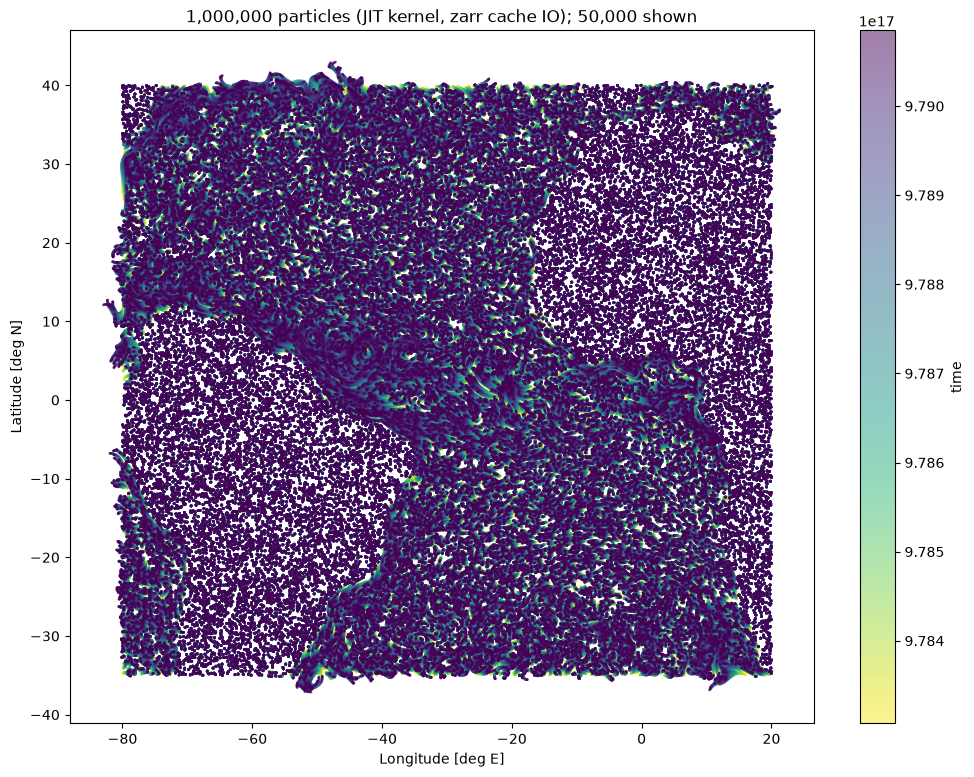

In [12]:
n_plot = min(50_000, n_particles)
plot_ids = rng.choice(n_particles, size=n_plot, replace=False)
mask = np.isin(df["particle_id"].to_numpy(), plot_ids)
_df = df[mask]

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    _df["lon"], _df["lat"], c=_df["time"], s=1, alpha=0.5, cmap="viridis_r"
)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title(f"{n_particles:,} particles (JIT kernel, zarr cache IO); {n_plot:,} shown")
fig.colorbar(scatter, ax=ax, label="time")
plt.show()